Training set size: (800, 7)
Testing set size: (200, 7)

📊 Logistic Regression Results
Accuracy: 0.965
Confusion Matrix:
 [[109   3]
 [  4  84]]
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.97      0.97       112
           1       0.97      0.95      0.96        88

    accuracy                           0.96       200
   macro avg       0.97      0.96      0.96       200
weighted avg       0.97      0.96      0.96       200


🌳 Decision Tree Results
Accuracy: 1.0
Confusion Matrix:
 [[112   0]
 [  0  88]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       112
           1       1.00      1.00      1.00        88

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200


🌲 Random Forest Results
Accuracy: 0.995
Confusion Matrix:
 [[112   0]
 [

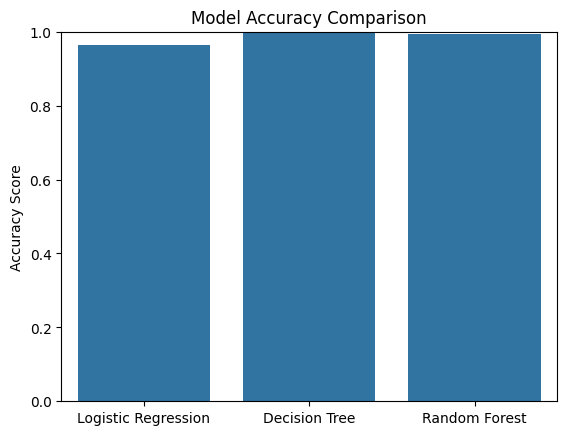


✅ Model training and evaluation completed successfully.


In [1]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

# 2. Load Cleaned Data
df = pd.read_csv('../Data/smart_admission_data.csv')

# 3. Encode Categorical Features
faculty_encoder = LabelEncoder()
department_encoder = LabelEncoder()

df['faculty_encoded'] = faculty_encoder.fit_transform(df['faculty'])
df['department_encoded'] = department_encoder.fit_transform(df['department'])

# Save the encoders
joblib.dump(faculty_encoder, 'Model/faculty_encoder.pkl')
joblib.dump(department_encoder, 'Model/department_encoder.pkl')

df['utme_scaled'] = df['utme_score'] / 400
df['screening_scaled'] = df['screening_score'] / 100

# 4. Prepare Features and Target
X = df[['faculty_encoded', 'department_encoded', 'utme_score','utme_scaled','screening_score','screening_scaled','olevel_passed']]
y = df['admitted']

# 5. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

# 6. Initialize Models
log_model = LogisticRegression(max_iter=1000)
tree_model = DecisionTreeClassifier(random_state=42)
rf_model = RandomForestClassifier(random_state=42)

# 7. Train Models
log_model.fit(X_train, y_train)
tree_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

# 8. Predictions
log_preds = log_model.predict(X_test)
tree_preds = tree_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)

# 9. Evaluate Models
print("\n📊 Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, log_preds))
print("Confusion Matrix:\n", confusion_matrix(y_test, log_preds))
print("Classification Report:\n", classification_report(y_test, log_preds))

print("\n🌳 Decision Tree Results")
print("Accuracy:", accuracy_score(y_test, tree_preds))
print("Confusion Matrix:\n", confusion_matrix(y_test, tree_preds))
print("Classification Report:\n", classification_report(y_test, tree_preds))

print("\n🌲 Random Forest Results")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))

# 10. Cross Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
log_cv_scores = cross_val_score(log_model, X, y, cv=cv, scoring='accuracy')
rf_cv_scores = cross_val_score(rf_model, X, y, cv=cv, scoring='accuracy')

print("\nLogistic Regression Cross-Validation Scores:", log_cv_scores)
print("Mean CV Accuracy:", log_cv_scores.mean())
print("\nRandom Forest Cross-Validation Scores:", rf_cv_scores)
print("Mean CV Accuracy:", rf_cv_scores.mean())

# 11. Plot Accuracy Comparison
models = ['Logistic Regression', 'Decision Tree', 'Random Forest']
accuracies = [
    accuracy_score(y_test, log_preds),
    accuracy_score(y_test, tree_preds),
    accuracy_score(y_test, y_pred_rf)
]

sns.barplot(x=models, y=accuracies)
plt.ylim(0, 1)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy Score')
plt.show()

# 12. Save Best Model (e.g., Random Forest)
joblib.dump(rf_model, 'Model/smart_admission_model.pkl')

print("\n✅ Model training and evaluation completed successfully.")